Here, you develop the 

In [2]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import time
import matplotlib.pyplot as plt
import itertools as it
from IPython.core.display import HTML


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [3]:
ceqSwitch = 'c1neqc2'
contSwitch = 'cont'
IRT = 'IRT'
derivative = False
BooleAve = False
WaveFunc = WFT.Gauss
appendage = '-' + ceqSwitch + '-' + contSwitch + '-' + IRT

if (ceqSwitch == 'c1eqc2'):
    val2 = 1
else:
    val2 = 0.25

if (contSwitch == 'cont'):
    plotCont = True
else:
    plotCont = False

In [4]:
save = True
nh_min = 256
refRatio = 2
CFL = np.sqrt(0.5)
x_0 = 0.
x_1 = 0.5
Hans = False

deriv = 'CD'
RK = 1
order = 2

L = 1.
locs = [x_1]
epsilons = [val2, 1]# 11.68]
mus = [1, 1]#0.99837]

if (locs == []):
    field = 'E'
    AnalFunc = WFT.Advect
    PropFunc = ST.AdvectRHS
else:
    field = 'EB'
    AnalFunc = WFT.WaveEq
    PropFunc = ST.WaveEqRHS

coarse = True
AMR = False
fine = False

saveTime = 10

allOrders = True
if (allOrders):
    if (order > 2):
        if (deriv == 'UD'):
            order = 1
        else:
            order = 2

Inititialize `Grid` objects on coarse, fine, and AMR grid.

In [6]:
omegaAMR = BT.Grid(nh_min)
refCells = nh_min // 2
finepart = list(np.arange(refCells) + int(nh_min // 4))
omegaAMR.AddPatch(refRatio, finepart)
degFreed = omegaAMR.degFreed
nh_max = omegaAMR.nh_max

omegaF = BT.Grid(nh_max)
omegaC = BT.Grid(nh_min)

Inititialize `PhysProps` objects on coarse, fine, and AMR grid.

In [8]:
physicsAMR = BT.PhysProps(omegaAMR, epsilons, mus, locs, L)
cVecAMR = physicsAMR.cVec
cMatAMR = physicsAMR.cMat
csAMR = physicsAMR.cs

physicsC = BT.PhysProps(omegaC, epsilons, mus, locs, L)
cVecC = physicsC.cVec
cMatC = physicsC.cMat
csC = physicsC.cs

physicsF = BT.PhysProps(omegaF, epsilons, mus, locs, L)
cVecF = physicsF.cVec
cMatF = physicsF.cMat
csF = physicsF.cs

c1 = csAMR[0]
mu1 = mus[0]
epsilon1 = epsilons[0]
if (locs ==[]):
    c2 = c1
    mu2 = mu1
    epsilon2 = epsilon1
else:
    c2 = csAMR[-1]
    mu2 = mus[-1]
    epsilon2 = epsilons[-1]

Harvesting values and creating operators.

In [10]:
# c = ConvertParams(permitivity, permeability, L)
# t, nt = ST.CalcTime(omegaC, CFL, csAMR[0], nt = nt) # CHANGE BACK TO OMEGAAMR!!!
sigma, mu = WFT.GaussParams(x_0, x_1 / 2)
wavesAMR = WT.MakeWaves(omegaAMR)
nullspace = OT.FindNullspace(omegaAMR, wavesAMR, Hans = Hans)
restrictOp = GTT.CoarsenOp(omegaAMR)

wavesF = WT.MakeWaves(omegaF)
wavesC = WT.MakeWaves(omegaC)

if (locs != []):
    wavesC = OT.Block(wavesC, var = 2)
    wavesF = OT.Block(wavesF, var = 2)
    wavesAMR = OT.Block(wavesAMR, var = 2)
    nullspace = OT.Block(nullspace, var = 2)
    restrictOp = OT.Block(restrictOp, var = 2)


# derivMat = TT.ExactSpatOp(omegaAMR)
# spatOp = -cMatF @ derivMat
# timePropOp = LA2.expm(t * spatOp)

# derivMatC = TT.ExactSpatOp(omegaC)
# spatOpC = -cMatC @ derivMatC
# timePropOpC = LA2.expm(t * spatOpC)

# opC = -cMatC @ OT.SpaceDeriv(omegaC, order, diff)
# opF = -cMatF @ OT.SpaceDeriv(omegaF, order, diff)
# opAMR = -cMatAMR @ OT.SpaceDeriv(omegaAMR, order, diff)

hC = np.concatenate((omegaC.h, omegaC.h))
hF = np.concatenate((omegaF.h, omegaF.h))
hAMR = np.concatenate((omegaAMR.h, omegaAMR.h))

degHalfC = int(nh_min / 2)
degHalfAMR = int(degFreed / 2)
degHalfF = int(nh_max / 2)

epsVecC = np.ones(nh_min, float)
epsVecAMR = np.ones(degFreed, float)
epsVecF = np.ones(nh_max, float)

epsVecC[:degHalfC] = epsilon1
epsVecC[degHalfC:] = epsilon2
epsVecF[:degHalfF] = epsilon1
epsVecF[degHalfF:] = epsilon2
epsVecAMR[:degHalfAMR] = epsilon1
epsVecAMR[degHalfAMR:] = epsilon2

muVecC = np.ones(nh_min, float)
muVecAMR = np.ones(degFreed, float)
muVecF = np.ones(nh_max, float)

muVecC[:degHalfC] = 1. / mu1
muVecC[degHalfC:] = 1. / mu2
muVecF[:degHalfF] = 1. / mu1
muVecF[degHalfF:] = 1. / mu2
muVecAMR[:degHalfAMR] = 1. / mu1
muVecAMR[degHalfAMR:] = 1. / mu2


muepsC = np.concatenate((epsVecC, muVecC))
muepsF = np.concatenate((epsVecF, muVecF))
muepsAMR = np.concatenate((epsVecAMR, muVecAMR))



# print(muepsC)
# print('')

Initialize waveform.

In [12]:
# # For Gaussian:
# waveInitC = WFT.Gauss(omegaC, physicsC, sigma, mu, BooleAve = False, deriv = False, cellAve = True)
# waveInitF = WFT.Gauss(omegaF, physicsF, sigma, mu)
args = [sigma, mu] # , 40]
if (coarse):
    waveInitC = WFT.InitCond(omegaC, physicsC, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)
if (fine):
    waveInitF = WFT.InitCond(omegaF, physicsF, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)
if (AMR):
    waveInitAMR = WFT.InitCond(omegaAMR, physicsAMR, WaveFunc, args, deriv = derivative, BooleAve = BooleAve, field = field)

# waveInitF = np.append(waveInitF, waveInitF)
if (coarse):
    FCoefsC = FFTT.FourierCoefs(wavesC, waveInitC)
if (fine):
    FCoefsF = FFTT.FourierCoefs(wavesF, waveInitF)
# FCoefsC1 = np.asarray(np.append(FCoefsC, FCoefsC))


YOU ARE RUNNING GAUSS! False



If\
$u (x, 0) = \sum_{k = 0} a_{k} e^{2 \pi i k x}$,\
then the propagated incoming part of the wave is\
$u_{I} (x, t) = \sum_{k = 0} a_{k} e^{2 \pi i k (x - c_{1} t)} \Theta (x_{s} - x)$,\
and the reflected part of the wave is\
$u_{R} (x, t) = \frac{c_{2} - c_{1}}{c_{1} + c_{2}} \sum_{k = 0} a_{k} e^{2 \pi i k (2 x_{s} - x - c_{1} t)} \Theta (x_{s} - x)$.\
Thus, we can just multiply the original coefficients by an operator which contains the waves $e^{2 \pi i k (x - c_{1} t)}$ in the region of the first medium for the propagated wave and the waves $e^{2 \pi i k (2 x_{s} - x - c_{1} t)}$ in the region of the first medium for the reflected wave. This operator is zero in the region of the second medium.\
\
For the transmitted portion, I used $x'$ derived from the Method of Characteristics,\
$x'(x, t) = (x - c_{1} t) \Theta (x_{s} - x) + \frac{c_{1} (x - c_{2} t) + (c_{2} - c_{1}) x_{s}}{c_{2}} \Theta (x - x_{s}) \Theta (x_{s} + c_{2} t - x) + (x - c_{2} t) \Theta [x - (x_{s} + c_{2} t)]$,\
and plugged it into the initial wave like so:\
$u_{T} (x, t) = \frac{2 c_{1}}{c_{1} + c_{2}} u [x' (x, t), 0] \Theta (x - x_{s})$.\
The scaling factor out front is semi-derived, semi-guess. The value I derived that it should have been was $\frac{2 c_{2}}{c_{1} + c_{2}}$, but changing the numerator to $c_{1}$ made the wave look more continuous for some reason.


In [14]:
t_snaps = 8
t_f = 3 / (4 * c1) # (3 / 8) * ((1 / c1) + (1 / c2))
t = 0
i = 0

ntVec = []#np.arange(iters) + 1
EVecCAnal = []#np.zeros(iters, float)
EVecAMRAnal = []#np.zeros(iters, float)
EVecFAnal = []#np.zeros(iters, float)
EVecCSolv = []#np.zeros(iters, float)
EVecAMRSolv = []#np.zeros(iters, float)
EVecFSolv = []

EVecCSolv2 = []
EVecCSolv3 = []

print('t_f =', t_f)


t_f = 0.375


This is what's happening.
BEFORE: t = 0.0

YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False

AFTER: t = 0.0

BEFORE: t = 0.013810679320049757

YOU ARE RUNNING GAUSS! False


YOU ARE RUNNING GAUSS! False

You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
You are using WaveEqRHS()!
Yo

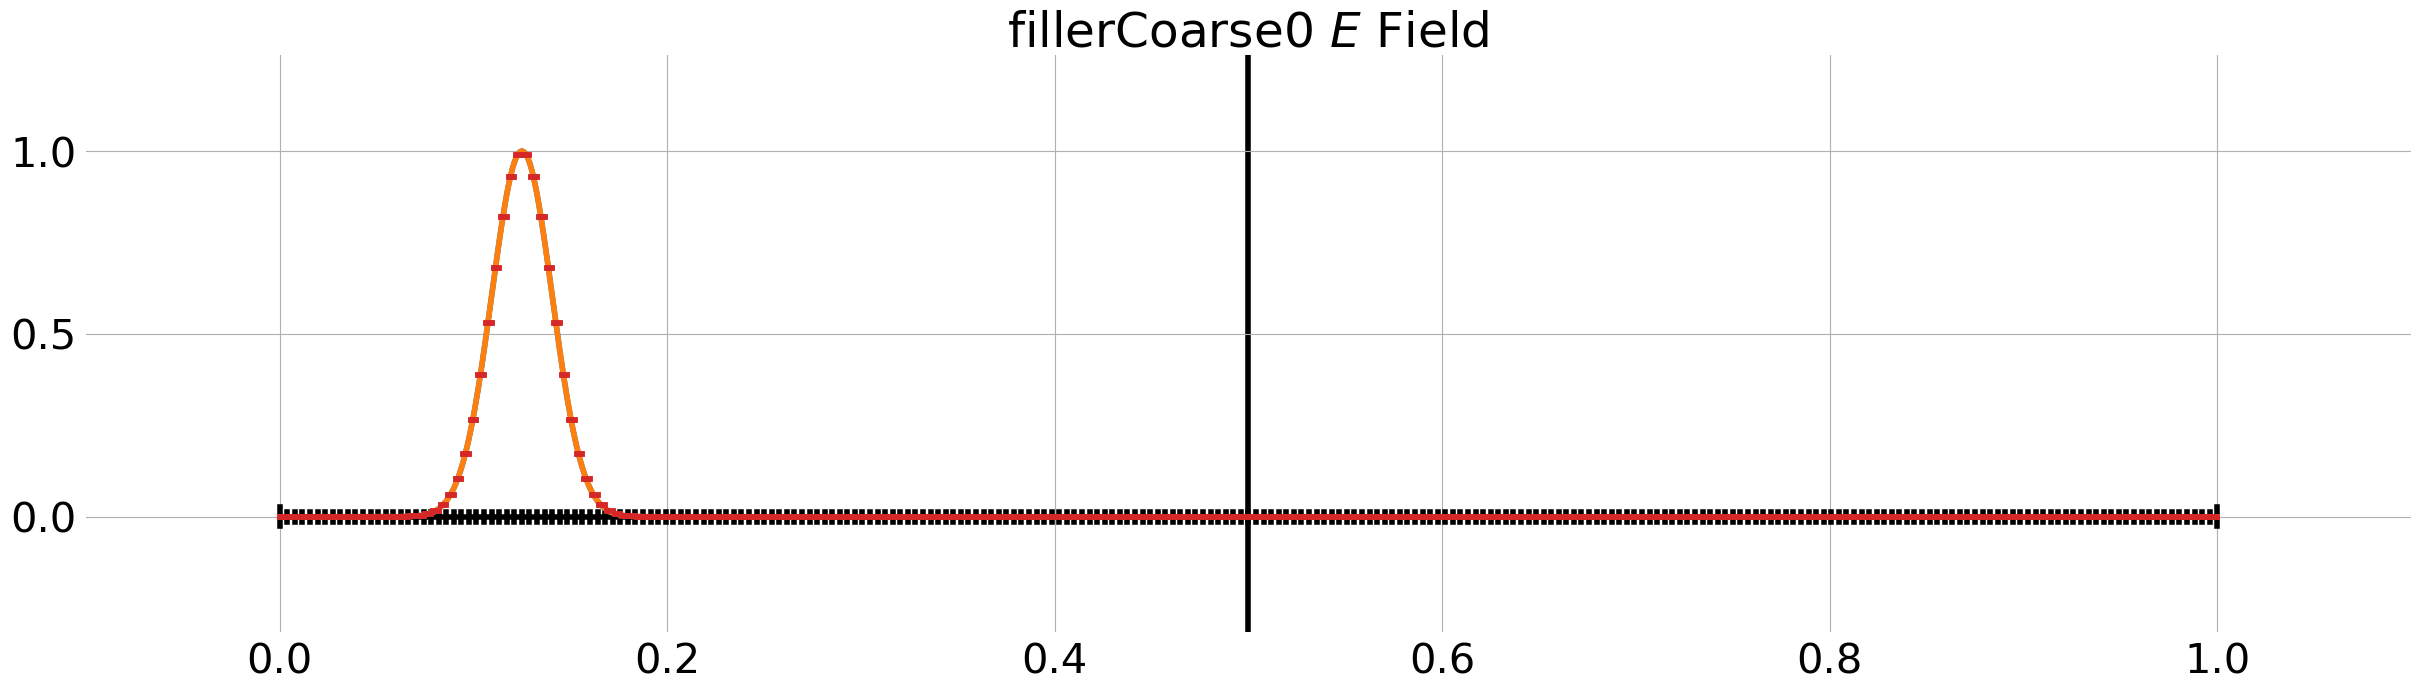

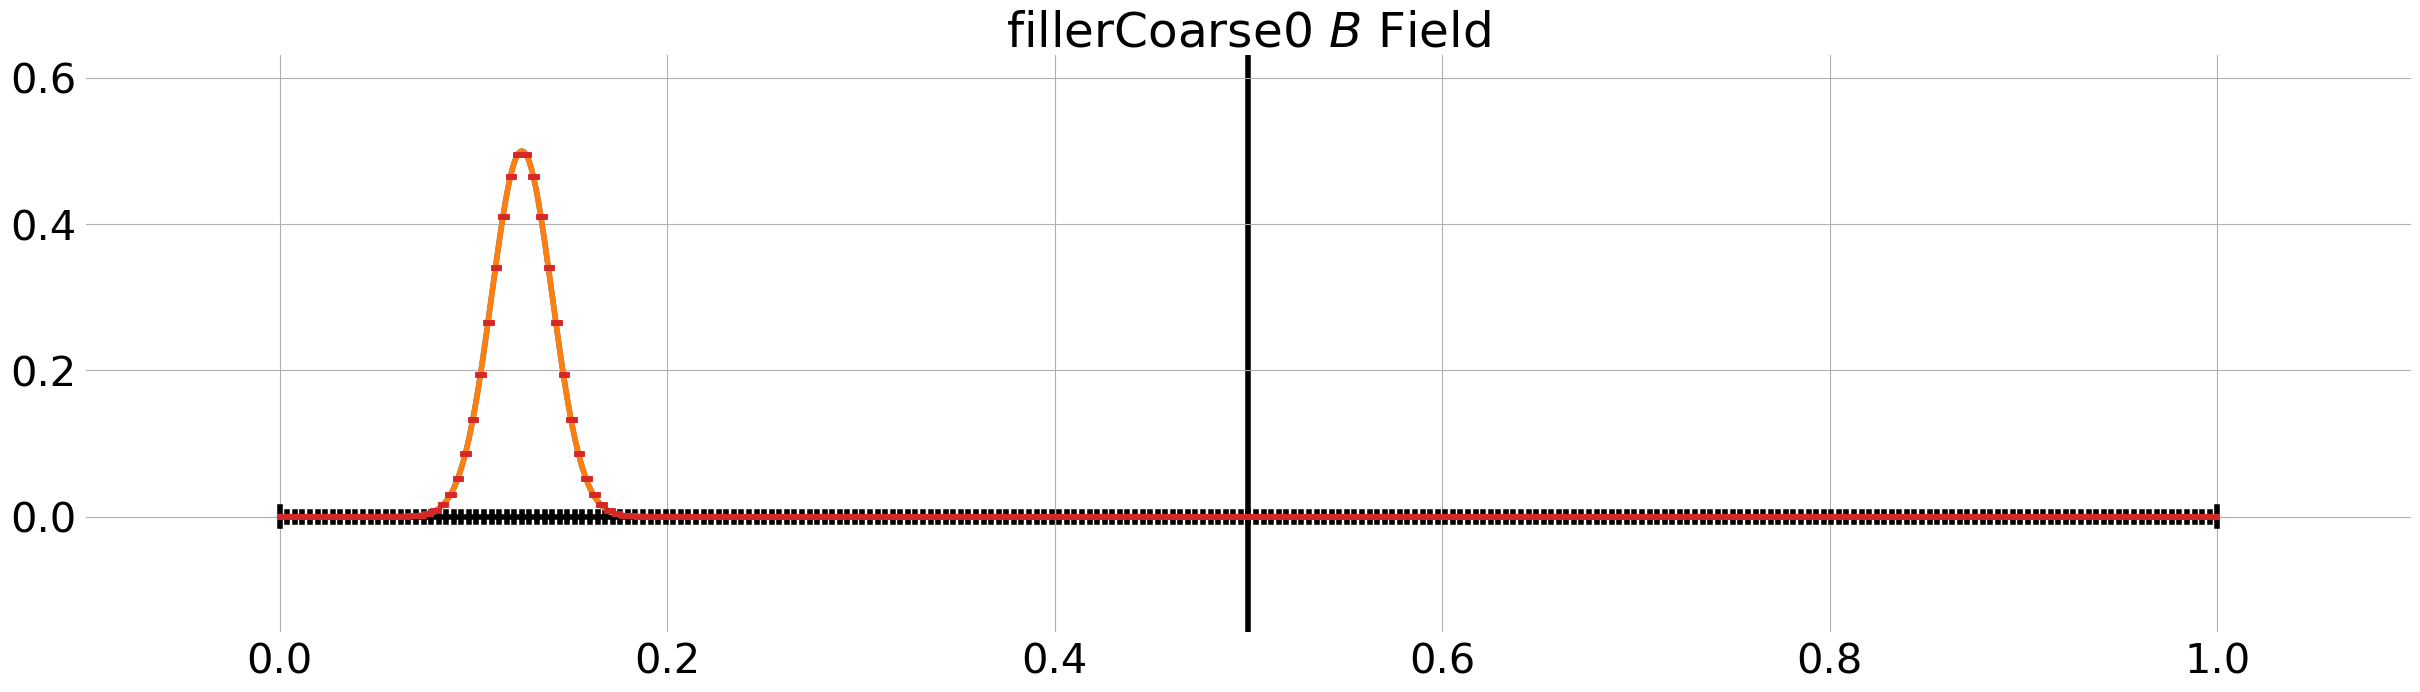

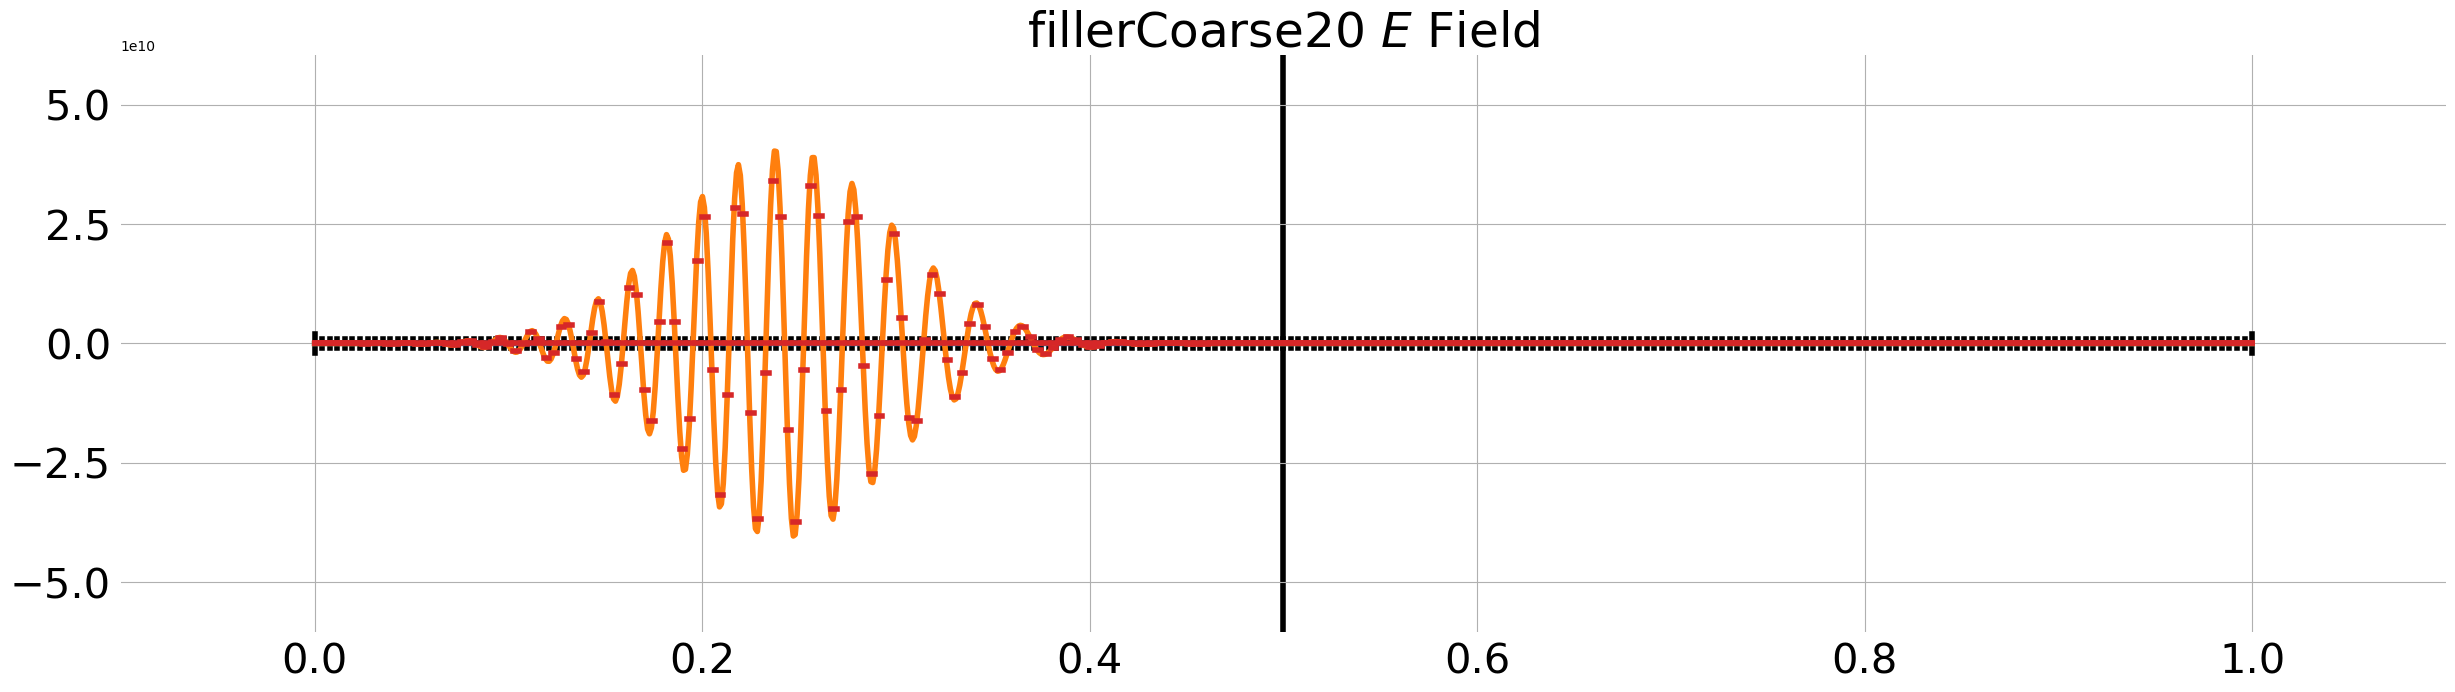

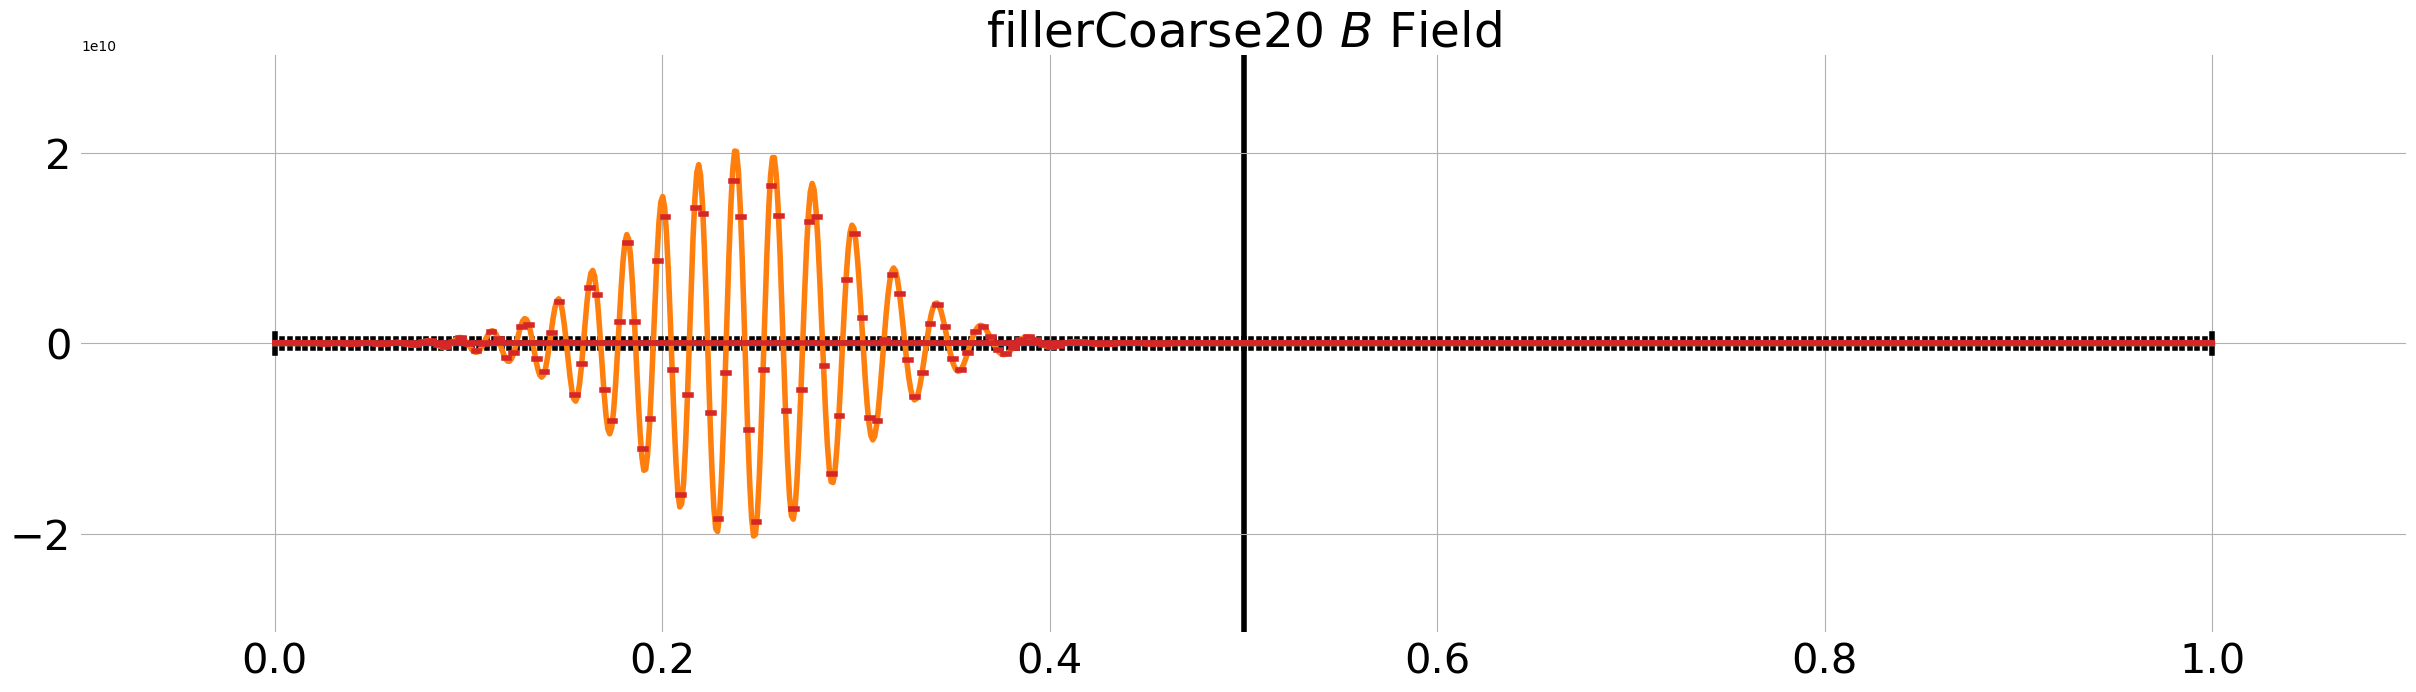

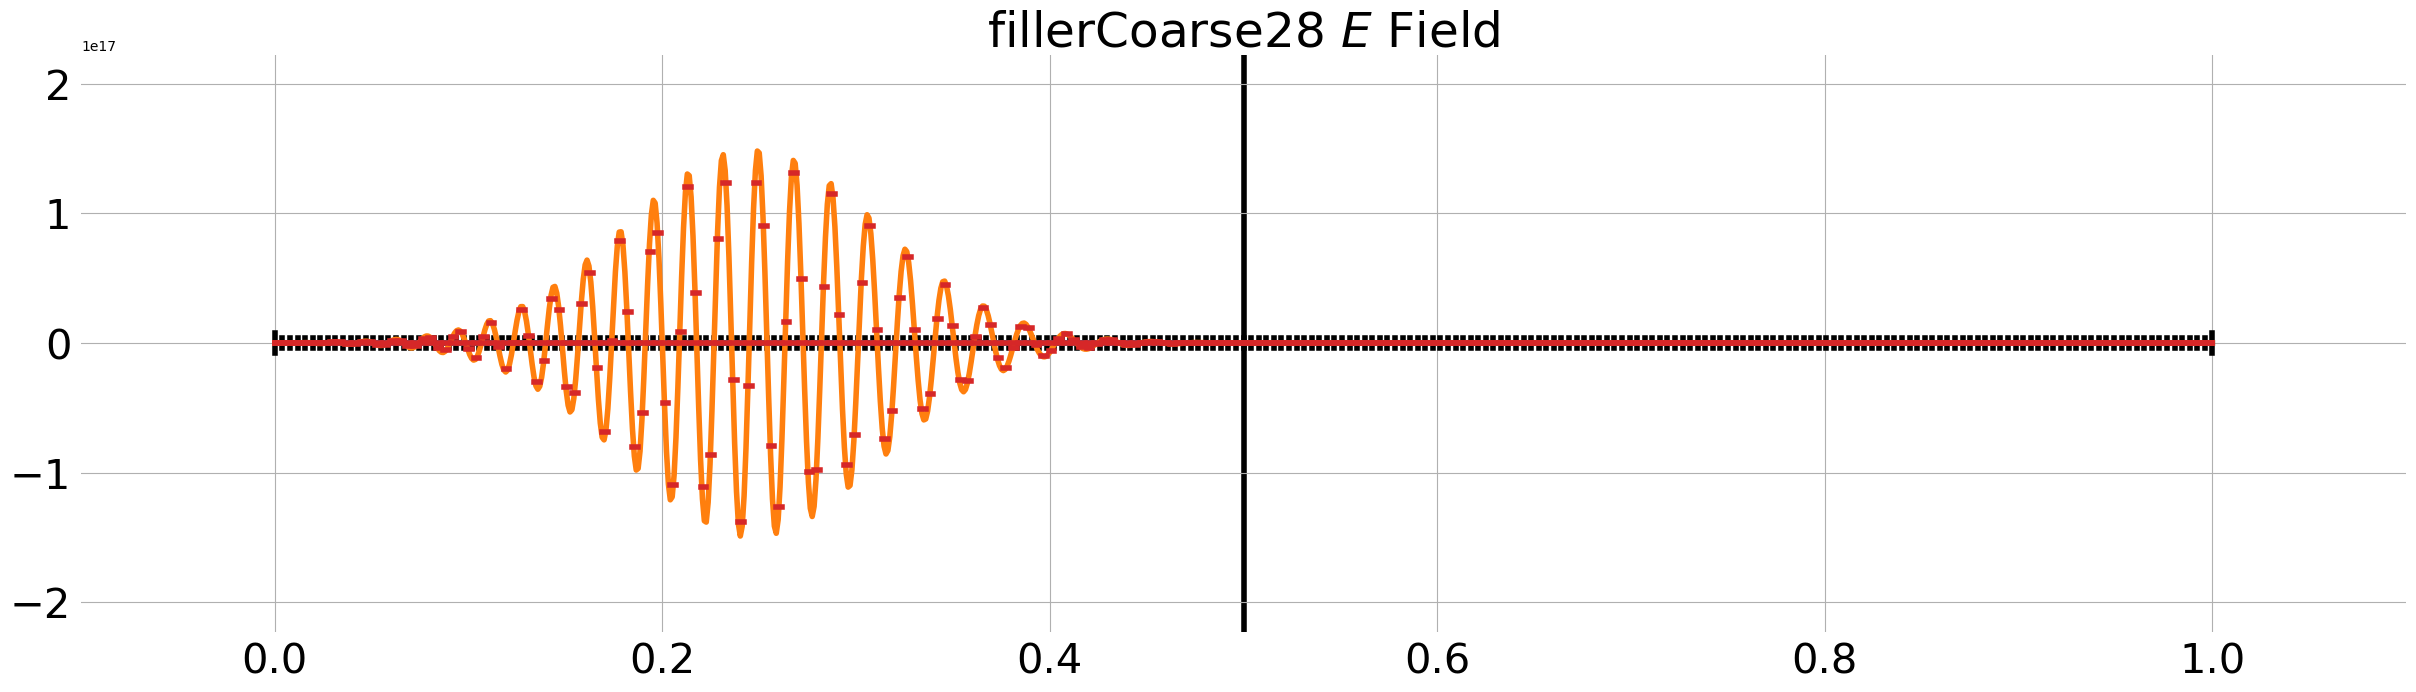

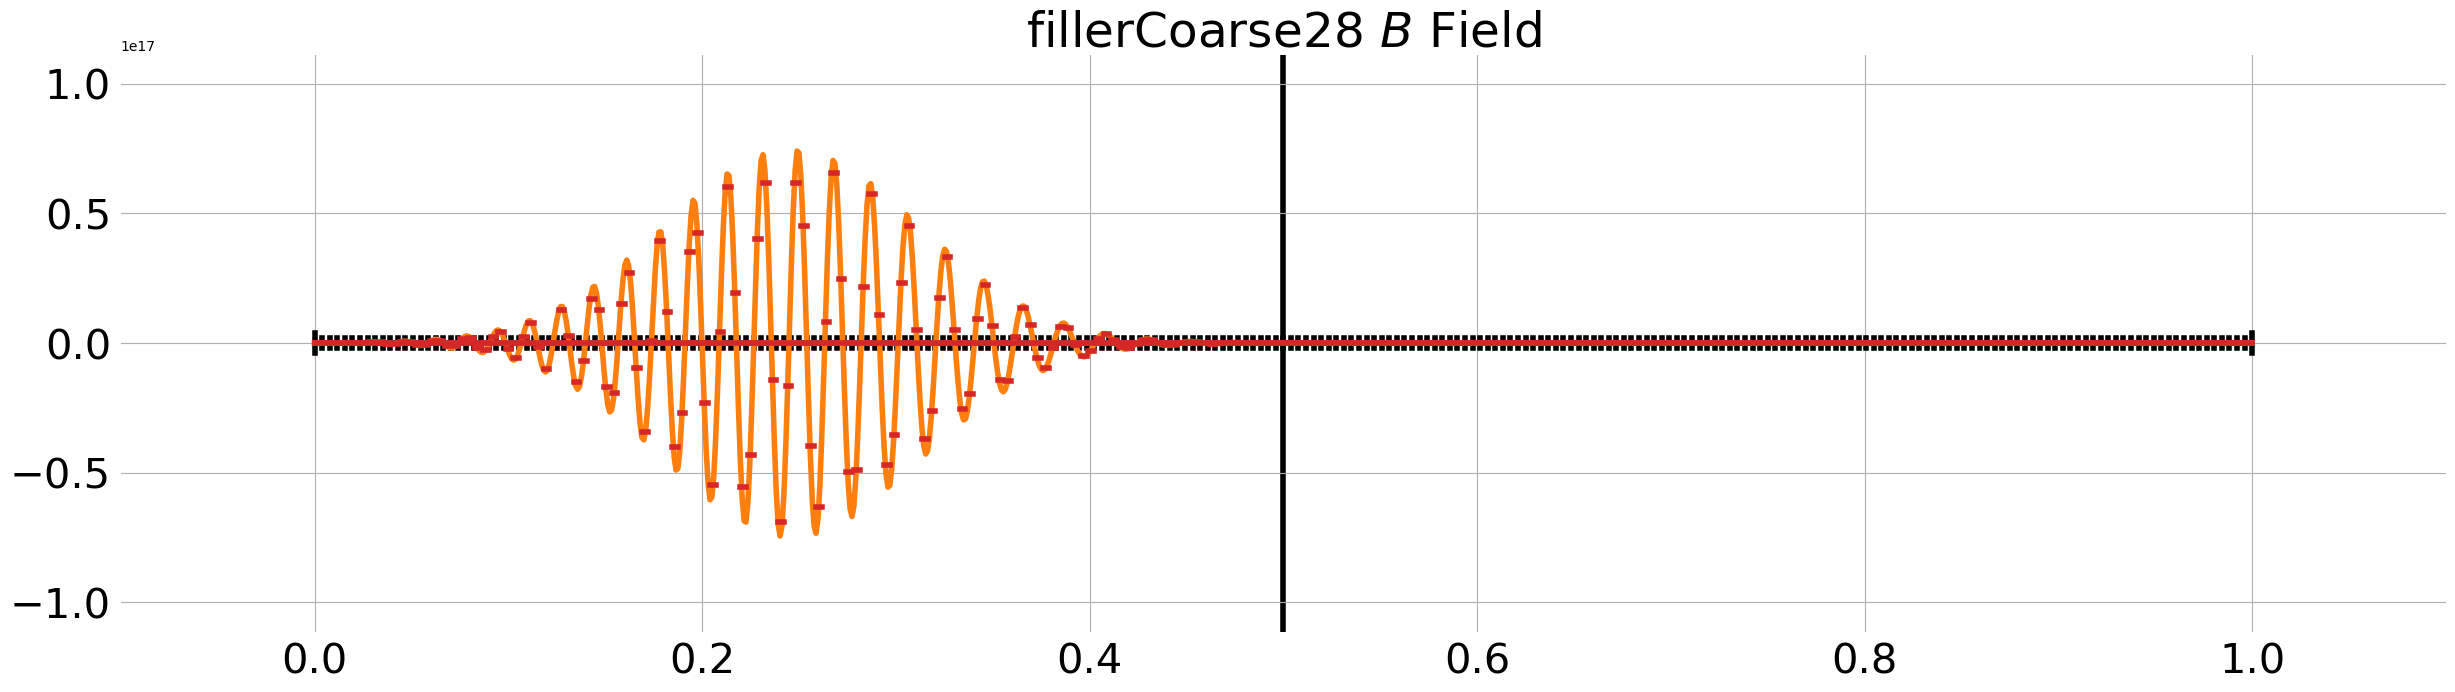

In [15]:
while (2 * t * saveTime <= t_f):
    t, nt = ST.CalcTime(omegaAMR, CFL, cMatAMR, nt = i)
#     t = (i * t_f) / (t_snaps - 1)
    print('BEFORE: t =', 2 * t * saveTime)
    if (coarse):
        # Find initial waveform on coarse grid.
        waveInitC = wavesC @ FCoefsC
        wavePropC = AnalFunc(omegaC, physicsC, WaveFunc, args, 2 * t * saveTime, deriv = derivative, BooleAve = BooleAve)#, IRT = IRT)#, field = field)#FFTT.FourierCoefs(wavesC, wavePropC) # timePropOpC @ FCoefsC
        # Find propagated coeficients on coarse grid.
        FCoefsPropC = FFTT.FourierCoefs(wavesC, wavePropC) # FFTT.FourierCoefs(wavesC, wavePropC) # timePropOpC @ FCoefsC
        # Find numerically propagated coefficients on coarse grid.
        solverCoefsC = ST.RungeKutta(omegaC, physicsC, waveInitC, CFL, nt * saveTime, RK, order, deriv, PropFunc)
        solvPropC = wavesC @ solverCoefsC
        if (allOrders):
            solverCoefsC2 = ST.RungeKutta(omegaC, physicsC, waveInitC, CFL, nt * saveTime, RK, order + 2, deriv, PropFunc)
            solvPropC2 = wavesC @ solverCoefsC2
            solverCoefsC3 = ST.RungeKutta(omegaC, physicsC, waveInitC, CFL, nt * saveTime, RK, order + 4, deriv, PropFunc)
            solvPropC3 = wavesC @ solverCoefsC3
        allCoefsC = PT.Load(FCoefsPropC, solverCoefsC)#, FCoefsPropCTh)

    if (fine):
        # Find initial waveform on fine grid.
        waveInitF = wavesF @ FCoefsF
        wavePropF = AnalFunc(omegaF, physicsF, WaveFunc, args, 2 * t * saveTime, deriv = derivative, BooleAve = BooleAve)#, IRT = IRT)#, field = field)
        # Find propagated coeficients on fine grid.
        FCoefsPropF = FFTT.FourierCoefs(wavesF, wavePropF)
        # Find numerically propagated coefficients on fine grid.
        solverCoefsF = ST.RungeKutta(omegaF, physicsF, waveInitF, CFL, 2 * nt * saveTime, RK, order, deriv, PropFunc)
        solvPropF = wavesF @ solverCoefsF
        allCoefsF = PT.Load(FCoefsPropF, solverCoefsF)#, FCoefsPropFTh)
        
    if (AMR):
        waveInitAMR = restrictOp @ waveInitF
        # Find Fourier coefficients for initial condition on AMR grid.
        FCoefsAMR = FFTT.FourierCoefs(wavesAMR @ nullspace, waveInitAMR)
        # Find analytically propagated waveform on AMR grid.
        wavePropAMR = AnalFunc(omegaAMR, physicsAMR, WaveFunc, args, 2 * t * saveTime, deriv = derivative, BooleAve = BooleAve)#, IRT = IRT)#, field = field) # restrictOp @ wavesF @ FCoefsPropF
        # Find analytically propagated coefficients on AMR grid.
        FCoefsPropAMR = FFTT.FourierCoefs(wavesAMR @ nullspace, wavePropAMR)
        # Find numerically propagated coefficients on AMR grid.     
        solverCoefsAMR = ST.RungeKutta(omegaAMR, physicsAMR, waveInitAMR, CFL, 2 * nt * saveTime, RK, order, deriv, PropFunc)
        solvPropAMR = wavesAMR @ nullspace @ solverCoefsAMR
        allCoefsAMR = nullspace @ PT.Load(FCoefsPropAMR, solverCoefsAMR)#, FCoefsPropAMRTh)

    

    # TEST FOR EXACT GAUSSIAN AT NEW LOCATION.

    # Find theoretical propagated coefficients on coarse, fine, and AMR grid. (THIS CAN ONLY BE USED IF MATERIAL IS UNIFORM!)
    # FCoefsPropCTh = FFTT.PropRestrictWaves(omegaC, waveInitC, c * t)
    # FCoefsPropFTh = FFTT.PropRestrictWaves(omegaF, waveInitF, c * t)
    # FCoefsPropAMRTh = FFTT.PropRestrictWaves(omega, waveInitF, c * t)

    # solverCoefsC = ST.RungeKutta(omegaC, physicsC, wavesC, waveInitC, nt, CFL, RK, op = opC) # TimeIntegratorFunc(omegaC, wavesC, waveInitC, nt, cMatC, CFL, DiffFunc)
    # solverCoefsF = ST.RungeKutta(omegaF, physicsF, wavesF, waveInitF, nt, CFL, RK, op = opF) # TimeIntegratorFunc(omegaF, wavesF, waveInitF, nt, cMatF, CFL, DiffFunc)
    # solverCoefsAMR = ST.RungeKutta(omegaAMR, physicsAMR, wavesAMR @ nullspace, waveInitAMR, nt, CFL, RK, op = opAMR) # TimeIntegratorFunc(omegaAMR, wavesAMR @ nullspace, waveInitAMR, nt, cMat, CFL, DiffFunc, order = order)
    # solverCoefsC1 = np.asarray(np.append(solverCoefsC, solverCoefsC))

    # print('')
    # print(np.round(FCoefsPropCTh, 14))
    # print(np.round(FCoefsPropFTh, 14))
    # print(np.round(FCoefsPropAMRTh, 14))



    # labels = ['Initial Wave', 'Method of Characteristics Propagated Wave']#, 'RK Propagated Wave']#, 'Rotation Matrix Propagated Wave']
    title = 'filler'
    if ((i % 20 == 0) or (2 * t * saveTime >= t_f)):
        # print('print t =', t)
        if (coarse):
            PT.PlotMixedWave(omegaC, physicsC, waves = wavesC, FCoefs = allCoefsC, rescale = [6, 3], xGrid = True, yGrid = True, title = title + 'Coarse' + str(i), dpi = 400, plotCont = plotCont, enlarge = True)
        if (AMR):
            PT.PlotMixedWave(omegaAMR, physicsAMR, waves = wavesAMR, FCoefs = allCoefsAMR, rescale = [6, 3], xGrid = True, yGrid = True, title = title + 'AMR' + str(i), dpi = 400, plotCont = plotCont, enlarge = True)#, labels = labels, title = 'AMR-Grid Mode Propagation', saveName = 'AMRHansMethod', dpi = 300)
        if (fine):
            PT.PlotMixedWave(omegaF, physicsF, waves = wavesF, FCoefs = allCoefsF, rescale = [6, 3], xGrid = True, yGrid = True, title = title + 'Fine' + str(i), dpi = 400, plotCont = plotCont, enlarge = True)#, labels = labels, title = 'Fine-Grid Mode Propagation', saveName = 'Fine', dpi = 300)
    

    if (locs == []):
        if (coarse):
            wavePropC = np.concatenate((wavePropC, wavePropC / c1))
            solvPropC = np.concatenate((solvPropC, solvPropC / c1))
            if (allOrders):
                solvPropC2 = np.concatenate((solvPropC2, solvPropC2 / c1))
                solvPropC3 = np.concatenate((solvPropC3, solvPropC3 / c1))
        if (fine):
            wavePropF = np.concatenate((wavePropF, wavePropF / c1))
            solvPropF = np.concatenate((solvPropF, solvPropF / c1))
        if (AMR):
            wavePropAMR = np.concatenate((wavePropAMR, wavePropAMR / c1))
            solvPropAMR = np.concatenate((solvPropAMR, solvPropAMR / c1))

    if (coarse):
        EVecCAnal = np.append(EVecCAnal, 0.5 * sum(muepsC * wavePropC * wavePropC * hC))
        EVecCSolv = np.append(EVecCSolv, 0.5 * sum(muepsC * solvPropC * solvPropC * hC))
        if (allOrders):
            EVecCSolv2 = np.append(EVecCSolv2, 0.5 * sum(muepsC * solvPropC2 * solvPropC2 * hC))
            EVecCSolv3 = np.append(EVecCSolv3, 0.5 * sum(muepsC * solvPropC3 * solvPropC3 * hC))
    if (fine):
        EVecFAnal = np.append(EVecFAnal, 0.5 * sum(muepsF * wavePropF * wavePropF * hF))
        EVecFSolv = np.append(EVecFSolv, 0.5 * sum(muepsF * solvPropF * solvPropF * hF))
    if (AMR):
        EVecAMRAnal = np.append(EVecAMRAnal, 0.5 * sum(muepsAMR * wavePropAMR * wavePropAMR * hAMR))
        EVecAMRSolv = np.append(EVecAMRSolv, 0.5 * sum(muepsAMR * solvPropAMR * solvPropAMR * hAMR))
    ntVec = np.append(ntVec, i)
    # print('Energy Coarse:', EVecC)
    # print('Energy AMR:', EVecAMR)
    # print('Energy Fine:', EVecF)
    print('AFTER: t =', 2 * t * saveTime)
    
    print('')
    i = i + 1
if (coarse):
    EVecCAnal = np.asarray(EVecCAnal)
    EVecCSolv = np.asarray(EVecCSolv)
    if (allOrders):
        EVecCSolv2 = np.asarray(EVecCSolv2)
        EVecCSolv3 = np.asarray(EVecCSolv3)
if (fine):
    EVecFAnal = np.asarray(EVecFAnal)
    EVecFSolv = np.asarray(EVecFSolv)
if (AMR):
    EVecAMRAnal = np.asarray(EVecAMRAnal)
    EVecAMRSolv = np.asarray(EVecAMRSolv)
ntVec = np.asarray(ntVec) * saveTime


In [16]:
coarse = True

numPoints, font, X, savePath = PT.UsefulPlotVals()

energy = epsilons[0] * sigma * (np.pi**0.5) * np.ones(i, float)

dt = 2 * t / nt
print(t_f, t)
print(i, nt, len(EVecFSolv))


peakCrossing = 3 / (8 * c1 * dt)

if (coarse):
    EDiffCAnal = abs(EVecCAnal - energy) / energy
    EDiffCAbs = abs(EVecCSolv - energy) / energy
    EDiffCRel = abs(EVecCSolv - EVecCAnal) / energy
    if (allOrders):
        EDiffCAbs2 = abs(EVecCSolv2 - energy) / energy
        EDiffCAbs3 = abs(EVecCSolv3 - energy) / energy
        EDiffCRel2 = abs(EVecCSolv2 - EVecCAnal) / energy
        EDiffCRel3 = abs(EVecCSolv3 - EVecCAnal) / energy
if (fine):
    EDiffFAnal = abs(EVecFAnal - energy) / energy
    EDiffFAbs = abs(EVecFSolv - energy) / energy
    EDiffFRel = abs(EVecFSolv - EVecFAnal) / energy
if (AMR):
    EDiffAMRAnal = abs(EVecAMRAnal - energy) / energy
    EDiffAMRAbs = abs(EVecAMRSolv - energy) / energy
    EDiffAMRRel = abs(EVecAMRSolv - EVecAMRAnal) / energy

if (coarse):
    minY = np.min(EDiffCAnal)
    maxY = np.max(EDiffCAnal)
    if (minY > np.min(EDiffCAbs)):
        minY = np.min(EDiffCAbs)
    if (maxY < np.max(EDiffCAbs)):
        maxY = np.max(EDiffCAbs)
    if (minY > np.min(EDiffCRel)):
        minY = np.min(EDiffCRel)
    if (maxY < np.max(EDiffCRel)):
        maxY = np.max(EDiffCRel)
if (fine):
    if (coarse):
        if (minY > np.min(EDiffFAnal)):
            minY = np.min(EDiffFAnal)
        if (maxY < np.max(EDiffFAnal)):
            maxY = np.max(EDiffFAnal)
    else:
        minY = np.min(EDiffFAnal)
        maxY = np.max(EDiffFAnal)
    if (minY > np.min(EDiffFAbs)):
        minY = np.min(EDiffFAbs)
    if (maxY < np.max(EDiffFAbs)):
        maxY = np.max(EDiffFAbs)
    if (minY > np.min(EDiffFRel)):
        minY = np.min(EDiffFRel)
    if (maxY < np.max(EDiffFRel)):
        maxY = np.max(EDiffFRel)
if (AMR):
    if (fine or coarse):
        if (minY > np.min(EDiffAMRAnal)):
            minY = np.min(EDiffAMRAnal)
        if (maxY < np.max(EDiffAMRAnal)):
            maxY = np.max(EDiffAMRAnal)
    else:
        minY = np.min(EDiffAMRAnal)
        maxY = np.max(EDiffAMRAnal)
    if (minY > np.min(EDiffAMRAbs)):
        minY = np.min(EDiffAMRAbs)
    if (maxY < np.max(EDiffAMRAbs)):
        maxY = np.max(EDiffARMAbs)
    if (minY > np.min(EDiffAMRRel)):
        minY = np.min(EDiffAMRRel)
    if (maxY < np.max(EDiffAMRRel)):
        maxY = np.max(EDiffAMRRel)

vertX = np.asarray([peakCrossing, peakCrossing])
vertY = np.asarray([0, maxY])
print(peakCrossing, vertX, vertY)

0.375 0.01933495104806966
29 28 0
135.7645019878171 [135.7645019878171 135.7645019878171] [0.000000000000000e+00 4.052420419232134e+34]


In [17]:
# if (reflux):
#     reflux = 'reflux'
# else:

# save = True
figsize = [10, 5] # For paper
if (deriv == 'UD'):
    titleAdd = ' Upwind Difference'
else:
    titleAdd = ' Center Difference'

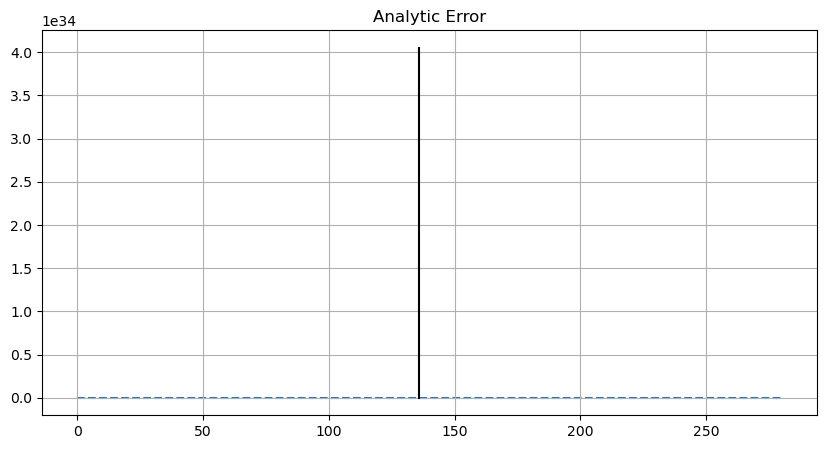

In [18]:
saveName = savePath + 'Plot1RK' + str(RK)
fig, ax = plt.subplots(figsize = figsize)
plt.title('Analytic Error')
if (coarse):
    plt.plot(ntVec, EDiffCAnal, color = PT.ColorDefault(0), linestyle = '--', zorder = 0)
if (AMR):
    plt.plot(ntVec, EDiffAMRAnal, color = PT.ColorDefault(0), linestyle = '-.', zorder = 1)
if (fine):
    plt.plot(ntVec, EDiffFAnal, color = PT.ColorDefault(0), linestyle = ':', zorder = 0)
if (locs != []):
    plt.plot(vertX, vertY, color = PT.ColorDefault(0.5), linestyle = '-')
# plt.yscale('log')
ax.grid(True, zorder = 0)
ax.set_axisbelow(True)
fig.canvas.draw()
if (save):
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = False)
plt.show()

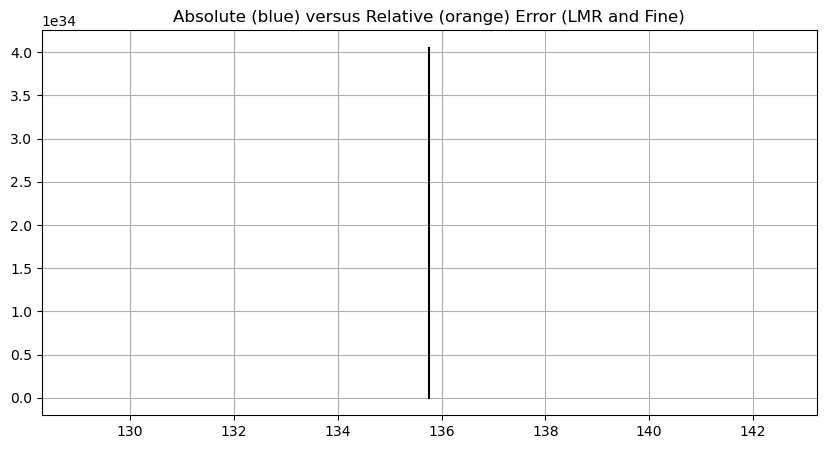

In [19]:
saveName = savePath + 'Plot2RK' + str(RK)
fig, ax = plt.subplots(figsize = figsize)
plt.title('Absolute (blue) versus Relative (orange) Error (LMR and Fine)')
if (AMR):
    plt.plot(ntVec, EDiffAMRAbs, color = PT.ColorDefault(0), linestyle = '-.', zorder = 1)
    plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
if (fine):
    plt.plot(ntVec, EDiffFAbs, color = PT.ColorDefault(0), linestyle = ':', zorder = 0)
    plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
if (locs != []):
    plt.plot(vertX, vertY, color = PT.ColorDefault(0.5), linestyle = '-')
# plt.yscale('log')
ax.grid(True, zorder = 0)
ax.set_axisbelow(True)
fig.canvas.draw()
if (save):
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = False)
plt.show()

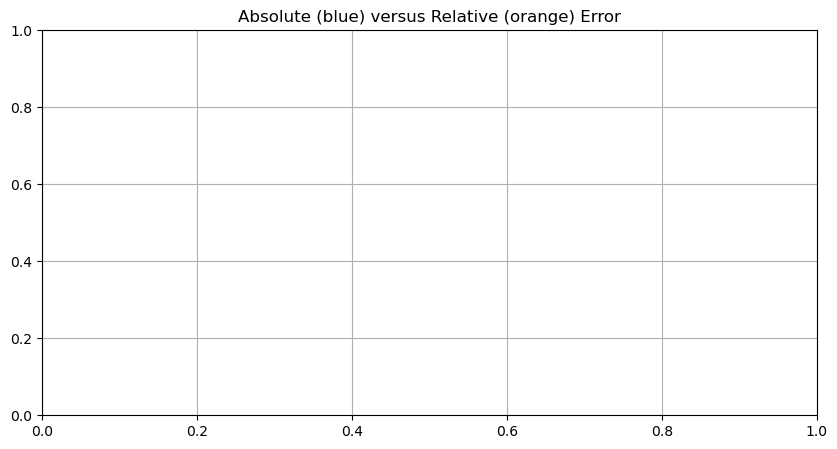

In [20]:
saveName = savePath + 'Plot3RK' + str(RK)
fig, ax = plt.subplots(figsize = figsize)
plt.title('Absolute (blue) versus Relative (orange) Error')
if (AMR):
    plt.plot(ntVec, EDiffAMRAbs, color = PT.ColorDefault(0), linestyle = '-.', zorder = 1)
    plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
if (fine):
    plt.plot(ntVec, EDiffFAbs, color = PT.ColorDefault(0), linestyle = ':', zorder = 0)
    plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
# plt.yscale('log')
ax.grid(True, zorder = 0)
ax.set_axisbelow(True)
fig.canvas.draw()
if (save):
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = False)
plt.show()

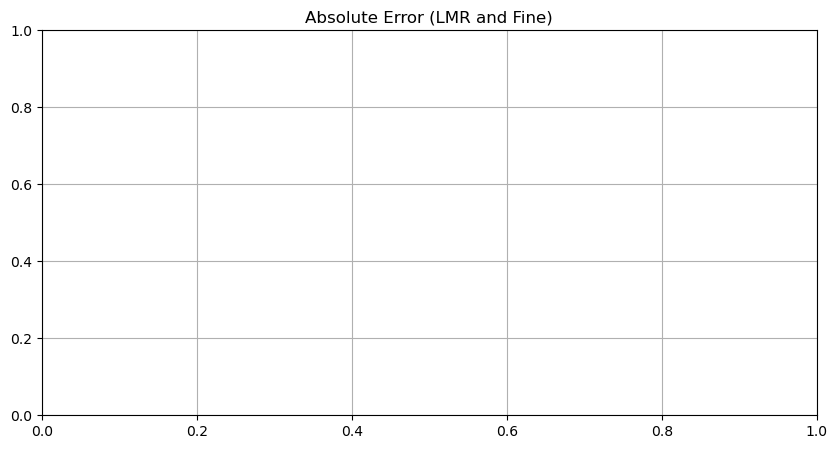

In [21]:
saveName = savePath + 'Plot4RK' + str(RK)
fig, ax = plt.subplots(figsize = figsize)
plt.title('Absolute Error (LMR and Fine)')
if (AMR):
    plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
if (fine):
    plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
# plt.yscale('log')
ax.grid(True, zorder = 0)
ax.set_axisbelow(True)
fig.canvas.draw()
if (save):
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = False)
plt.show()

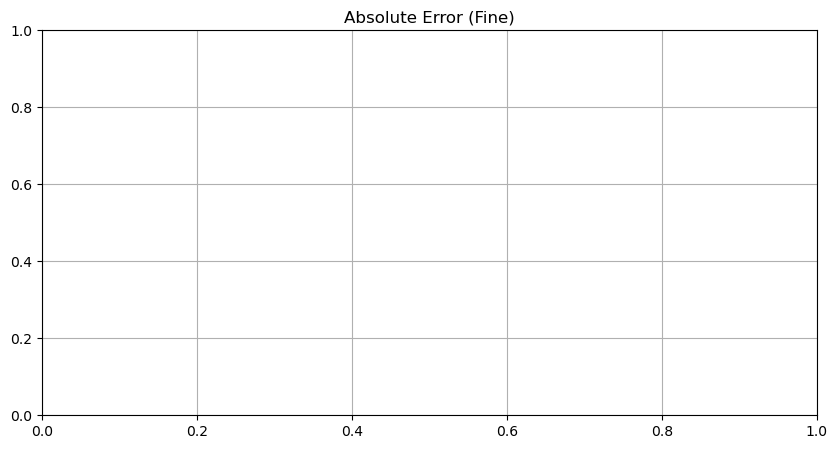

In [22]:
saveName = savePath + 'Plot5RK' + str(RK)
fig, ax = plt.subplots(figsize = figsize)
plt.title('Absolute Error (Fine)')
if (fine):
    plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
# plt.yscale('log')
ax.grid(True, zorder = 0)
ax.set_axisbelow(True)
fig.canvas.draw()
if (save):
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = False)
plt.show()

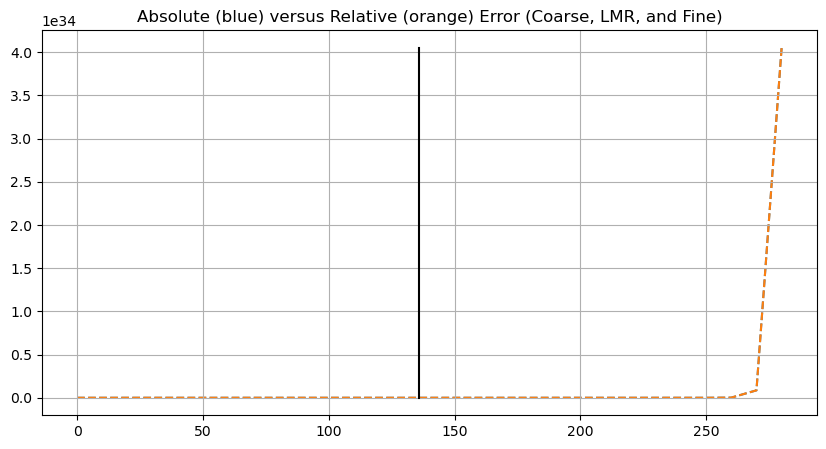

In [23]:
saveName = savePath + 'Plot6RK' + str(RK)
fig, ax = plt.subplots(figsize = figsize)
plt.title('Absolute (blue) versus Relative (orange) Error (Coarse, LMR, and Fine)')
if (coarse):
    plt.plot(ntVec, EDiffCAbs, color = PT.ColorDefault(0), linestyle = '--', zorder = 0)
    plt.plot(ntVec, EDiffCRel, color = PT.ColorDefault(1), linestyle = '--', zorder = 0)
if (AMR):
    plt.plot(ntVec, EDiffAMRAbs, color = PT.ColorDefault(0), linestyle = '-.', zorder = 1)
    plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
if (fine):
    plt.plot(ntVec, EDiffFAbs, color = PT.ColorDefault(0), linestyle = ':', zorder = 0)
    plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
if (locs != []):
    plt.plot(vertX, vertY, color = PT.ColorDefault(0.5), linestyle = '-')
# plt.yscale('log')
ax.grid(True, zorder = 0)
ax.set_axisbelow(True)
fig.canvas.draw()
if (save):
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = False)
plt.show()

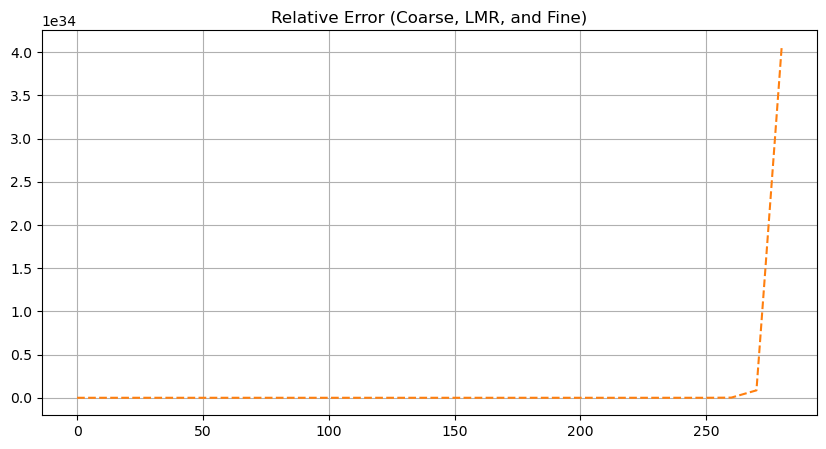

In [24]:
saveName = savePath + 'Plot7RK' + str(RK)
fig, ax = plt.subplots(figsize = figsize)
plt.title('Relative Error (Coarse, LMR, and Fine)')
if (AMR):
    plt.plot(ntVec, EDiffAMRRel, color = PT.ColorDefault(1), linestyle = '-.', zorder = 1)
if (coarse):
    plt.plot(ntVec, EDiffCRel, color = PT.ColorDefault(1), linestyle = '--', zorder = 1)
if (fine):
    plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 1)
# plt.yscale('log')
ax.grid(True, zorder = 0)
ax.set_axisbelow(True)
fig.canvas.draw()
if (save):
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = False)
plt.show()

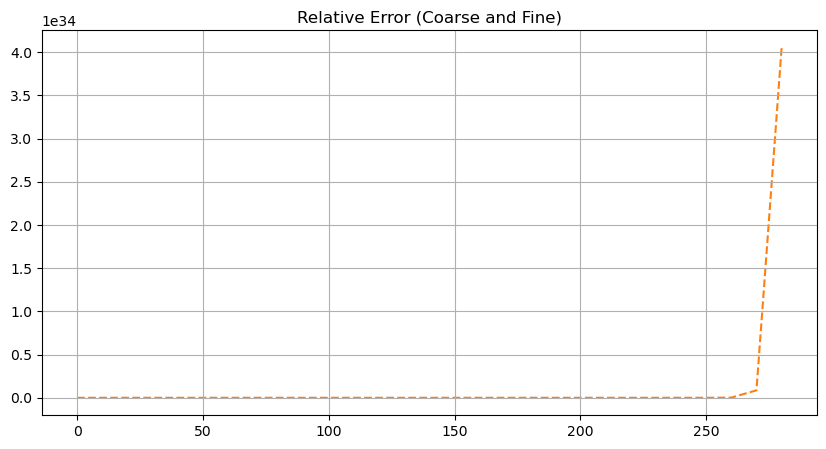

In [25]:
saveName = savePath + 'Plot8RK' + str(RK)
fig, ax = plt.subplots(figsize = figsize)
plt.title('Relative Error (Coarse and Fine)')
if (coarse):
    plt.plot(ntVec, EDiffCRel, color = PT.ColorDefault(1), linestyle = '--', zorder = 0)
if (fine):
    plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 0)
# plt.yscale('log')
ax.grid(True, zorder = 0)
ax.set_axisbelow(True)
fig.canvas.draw()
if (save):
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = False)
plt.show()

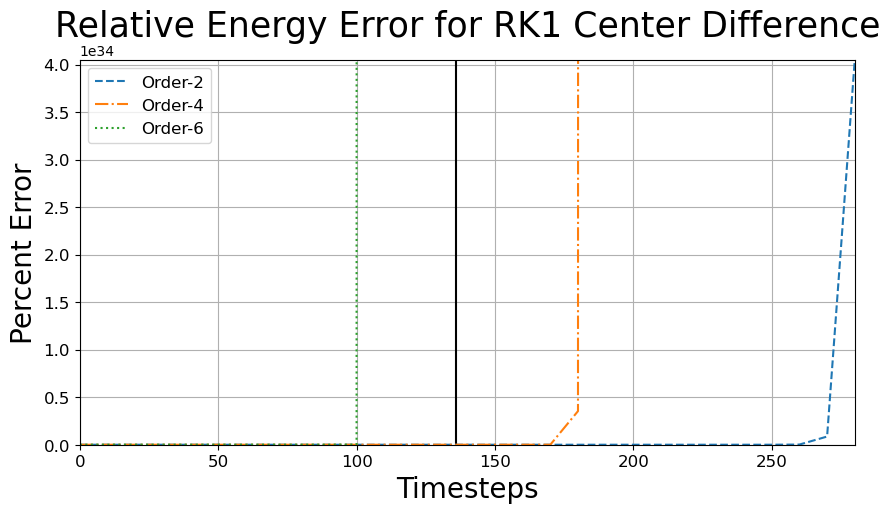

In [26]:
saveName = savePath + 'EnergyErrorUniformRK' + str(RK) + deriv
fig, ax = plt.subplots(figsize = figsize)
plt.title('Relative Energy Error for RK' + str(RK) + titleAdd, fontsize = 25)
plt.xlabel('Timesteps', fontsize = 20)
plt.ylabel('Percent Error', fontsize = 20)
if (coarse):
    plt.plot(ntVec, EDiffCRel, color = PT.ColorDefault(0), linestyle = '--', zorder = 2, label = 'Order-' + str(order))
    if (allOrders):
        plt.plot(ntVec, EDiffCRel2, color = PT.ColorDefault(1), linestyle = '-.', zorder = 2, label = 'Order-' + str(order + 2))
        plt.plot(ntVec, EDiffCRel3, color = PT.ColorDefault(2), linestyle = ':', zorder = 2, label = 'Order-' + str(order + 4))
if (fine):
    plt.plot(ntVec, EDiffFRel, color = PT.ColorDefault(1), linestyle = ':', zorder = 2)
# plt.yscale('log')
if (locs != []):
    plt.plot(vertX, vertY, color = PT.ColorDefault(0.5), linestyle = '-', zorder = 1)
ax.grid(True, zorder = 0)
ax.tick_params(labelsize = 12)
ax.set_axisbelow(True)
fig.canvas.draw()
plt.legend(loc = 'upper left', fontsize = 12)
plt.xlim(0, ntVec[-1])
plt.ylim(0, vertY[-1])
if (save):
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 400, transparent = False)
plt.show()

In [27]:
if (coarse):
    print(EDiffCRel)
if (fine):
    print(EDiffFRel)
if (AMR):
    print(EDiffAMRRel)

[3.7721019049421193e-16 1.8778656419169851e-01 5.1432978634091442e-01 1.2070831775239701e+00 3.1862218331485619e+00 1.1569064700271362e+01 6.5971636089704532e+01 5.8289659978515010e+02 7.2454908785428261e+03 1.1600911742892049e+05 2.2508286542737726e+06 5.0742227988852337e+07 1.2897275072781045e+09 3.6143847102152863e+10 1.0980081385037477e+12 3.5685127464163461e+13 1.2278891062062328e+15 4.4360798293208288e+16 1.6713555063127601e+18 6.5306416871218209e+19 2.6342776130230115e+21 1.0927336272344675e+23 4.6462749192928965e+24 2.0194655385078330e+26 8.9512884612443788e+27 4.0380505684528898e+29 1.8506879713155846e+31 8.6041348863156245e+32 4.0524204192321342e+34]


In [28]:
if (coarse):
    print('Coarse Max Norm:', np.max(EDiffCRel))
    print('')
if (AMR):
    print('LMR Max Norm:', np.max(EDiffAMRRel))
    print('')
if (fine):
    print('Fine Max Norm:', np.max(EDiffFRel))
    print('')

Coarse Max Norm: 4.052420419232134e+34



In [29]:
X = []

for q in range(11):
    X = np.append(X, q)
half = (10 // 2) + 1
print(X)
print(X[::2])
print(X[:half])

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[ 0.  2.  4.  6.  8. 10.]
[0. 1. 2. 3. 4. 5.]


In [30]:
print(c1, c2)

2.0 1.0


In [31]:
print(EVecCSolv)
print(energy)
print('')

[6.8801968495401022e-03 8.1755930354818138e-03 1.0428165504326792e-02 1.5206942434398480e-02 2.8859509522897533e-02 8.6686344601120791e-02 4.6196816407864366e-01 4.0278389667712391e+00 4.9987991943260290e+01 8.0026524212352660e+02 1.5526755913094112e+04 3.5003191084454732e+05 8.8968457478068322e+06 2.4932881585118446e+08 7.5743201377283363e+09 2.4616445916084283e+11 8.4702698075629688e+12 3.0601129085939062e+14 1.1529406044300662e+16 4.5049912754213517e+17 1.8171870747569127e+19 7.5379353100297804e+20 3.2051104588848488e+22 1.3930751475666074e+24 6.1748107389211170e+25 2.7855428994769715e+27 1.2766483852183860e+29 5.9353359826549192e+30 2.7954555628094676e+32]
[0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.006898236790888443 0.0068982367908